In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]= os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY") 
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct-agent"

In [4]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

### tavily search tools
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

/var/folders/sl/j703510j7nv1c56nnpn57ps40000gn/T/ipykernel_63421/2077886238.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


arxiv
wikipedia


/var/folders/sl/j703510j7nv1c56nnpn57ps40000gn/T/ipykernel_63421/2077886238.py:14: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [5]:
### Custom Funtions
def multiply(a: int, b:int) -> int:
    """Multiply a and b
    Args:
    a: first int
    b: second int
    """
    return a * b

# this will be a tool
def add(a: int, b: int)-> int:
    """Adds a and b
    Args:
        a: first int
        b: second int
    
    """
    return a + b

def divide(a: int, b:int ) -> float:
    """Divide a and b
    Args:
        a: first int
        b: second int
    
    """
    return a/b

tools=[tavily,wiki,add, multiply, divide]



In [6]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")
llm_with_tools = llm.bind_tools(tools)

               

In [9]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent AI news. I need to figure out which tool to use here. Let me check the available functions.\n\nThe tools provided include a search engine (tavily_search_results_json) optimized for current events, a Wikipedia wrapper, and basic math functions. Since the user is asking about recent news, the search engine is the best bet because Wikipedia might not have the most up-to-date information. The math functions are irrelevant here. \n\nSo I\'ll use the tavily_search_results_json function with the query "recent AI News". That should fetch the latest information on AI developments. I need to make sure the query is correctly formatted as a JSON object within the tool_call tags. Let me structure that properly.\n', 'tool_calls': [{'id': 'x3r655x9r', 'function': {'arguments': '{"query":"recent AI News"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'

In [10]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI News'},
  'id': 'zsqqcpmcn',
  'type': 'tool_call'}]

In [11]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]

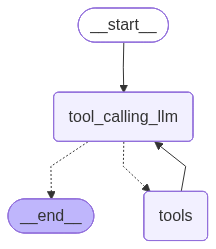

In [12]:
### Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
messages = graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news fir June,2026, add 5 plus 5 and then multiply by 10")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news fir June,2026, add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (rr1v7bmw0)
 Call ID: rr1v7bmw0
  Args:
    query: top 10 recent AI news June 2026
  add (3t0k3qhzf)
 Call ID: 3t0k3qhzf
  Args:
    a: 5
    b: 5
  multiply (an9j0rv3y)
 Call ID: an9j0rv3y
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Five Trends in AI and Data Science for 2026", "url": "https://sloanreview.mit.edu/article/five-trends-in-ai-and-data-science-for-2026", "content": "Carolyn Geason-Beissel/MIT SMR | Getty Images\n\nSummary: \n\nMIT SMR columnists Thomas H. Davenport and Randy Bean see five AI trends to pay attention to in 2026: deflation of the AI bubble and subsequent hits to 

In [16]:
messages = graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages["messages"]:
    print(m)

content='What is machine learning' additional_kwargs={} response_metadata={} id='0f409ca7-af96-45a3-a5ca-dc3c88cbcfe4'
content='' additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is machine learning?" I need to provide a clear and accurate explanation. Let me start by recalling the basics of machine learning. It\'s a subset of artificial intelligence that focuses on building systems that learn from data. Instead of being explicitly programmed for specific tasks, these systems use algorithms to find patterns in data and make decisions or predictions.\n\nI should mention the different types of machine learning, like supervised, unsupervised, and reinforcement learning. Supervised learning uses labeled data, unsupervised deals with unlabeled data, and reinforcement learning involves learning through interactions and rewards. Examples might help, such as classification, clustering, or recommendation systems.\n\nWait, the user might not be familiar with technical term